### Size of dataset

In [105]:
import os
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torch import nn as nn
from sklearn.model_selection import train_test_split
from torchvision.models import resnet18, ResNet18_Weights
import torch.optim as optim
import wandb
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

for file in ['test', 'train']:
    for f in ['NORMAL', 'PNEUMONIA']:
        path = f"chest_xray/{file}/{f}"
        print(f"{file}/{f} - {len(os.listdir(path))}")

test/NORMAL - 234
test/PNEUMONIA - 390
train/NORMAL - 1349
train/PNEUMONIA - 3883


### Transformations

In [94]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=(-5, 5)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

train_transforms_noaug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

### Load dataset and Dataloaders

In [95]:
train_data = datasets.ImageFolder("chest_xray/train", transform=train_transforms)
val_data = datasets.ImageFolder("chest_xray/train", transform=test_transforms)
test_data = datasets.ImageFolder("chest_xray/test", transform=test_transforms)

train_data_noaug = datasets.ImageFolder("chest_xray/train", transform=train_transforms_noaug)

targets = train_data.targets
num_samples = len(train_data)
indices = list(range(num_samples))

train_indices, val_indices = train_test_split(indices, test_size=0.2, stratify=targets, random_state=42)

train_dataset = Subset(train_data, train_indices)
val_dataset = Subset(val_data, val_indices)

train_dataset_noaug = Subset(train_data_noaug, train_indices)

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)
train_dataloader_noaug = DataLoader(train_dataset_noaug, batch_size=64, shuffle=True)

### Size of batch and sample photos

In [82]:
images, labels = next(iter(train_dataloader))
images.shape

torch.Size([64, 3, 224, 224])

In [83]:
def denormalize(tensor, std, mean):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor.clamp(0, 1)

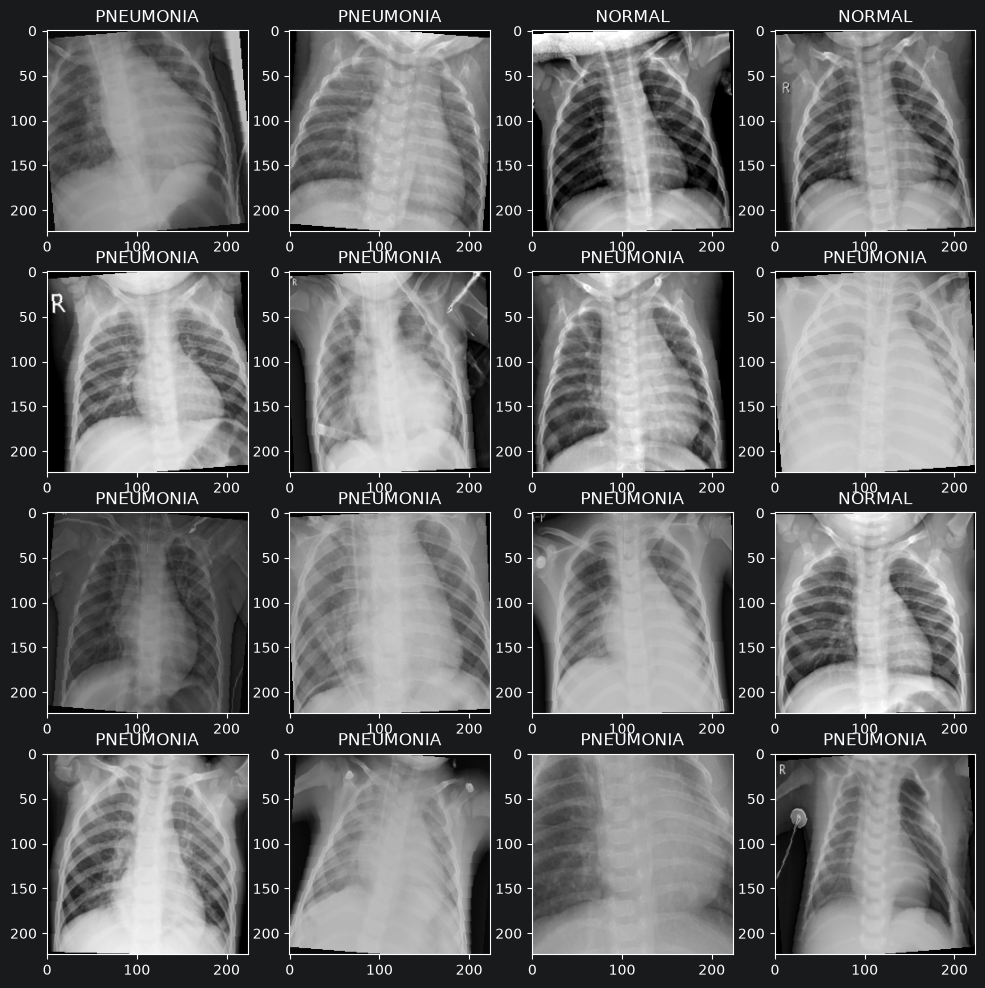

In [84]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for img, label, ax in zip(images, labels, axes):
    img_denorm = denormalize(img, std, mean)
    ax.imshow(img_denorm.permute(1, 2, 0), cmap='gray')
    ax.set_title(train_data.classes[label])
plt.show()

### ResNet18, Freezing backbone

In [96]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc

Linear(in_features=512, out_features=1000, bias=True)

### Head change and Train loop

In [99]:
model.fc = nn.Linear(512, 2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(lr):
    wandb.init(
        project='Pneumonia-Classifier',
        name=f'lr: {lr}-aug:False-rerun',
        config={'lr': lr, 'batch_size': 64, 'epochs': 20, 'Augmentation': False}
    )

    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=lr)

    for epoch in range(20):
        model.train()
        running_loss = 0.0
        for X, y in train_dataloader_noaug:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            result = model(X)
            loss = criterion(result, y)
            running_loss += loss.item()
            loss.backward()
            optimizer.step()
        avg_loss = running_loss / len(train_dataloader_noaug)


        model.eval()
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for X, y in val_dataloader:
                X, y = X.to(device), y.to(device)
                result = model(X)
                probs = torch.softmax(result, dim=1)
                predictions = (probs[:, 1] >= 0.3).int()
                all_preds.extend(predictions.cpu().numpy())
                all_labels.extend(y.cpu().numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds)
        recall = recall_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds)
        wandb.log({"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1, "loss": avg_loss, "epoch": epoch})
    wandb.finish()

train_model(lr=0.001)

wandb: setting up run 2sagzr5t
wandb: Tracking run with wandb version 0.28.2
wandb: Run data is saved locally in C:\Users\kubak\Documents\Programming\PycharmProjects\MachineLearning\PneumoniaClassifier\wandb\run-20260910_190340-2sagzr5t
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run lr: 0.001-aug:False-rerun
wandb:  View project at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/Pneumonia-Classifier
wandb:  View run at https://wandb.ai/jacob_21-agh-univeristy-of-krakow/Pneumonia-Classifier/runs/2sagzr5t
wandb: updating run metadata
wandb: uploading data
wandb: 
wandb: Run history:
wandb:  accuracy ▁▆▃▇▇█▇▇▇█▇▇▆▇▇█▆███
wandb:     epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:        f1 ▁▆▃▇▇█▇▇▇█▇▇▆▇▇█▆███
wandb:      loss █▃▃▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁
wandb: precision ▁▆▃▆▆█▇▇▇▇▆▆▅▆▆█▆▇█▇
wandb:    recall ▆▃▇▃▆▃▃▃▃▅▆▇█▆▆▃▇▄▁▆
wandb: 
wandb: Run summary:
wandb:  accuracy 0.97039
wandb:     epoch 19
wandb:        f1 0.98027
wandb:      loss 0.09741
wandb: precision 0.96977
wandb:    rec

In [114]:
all_probs = []
all_labels = []
predict = []

model.eval()
with torch.no_grad():
    for X, y in val_dataloader:
        X, y = X.to(device), y.to(device)
        result = model(X)
        probs = torch.softmax(result, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())
        all_labels.extend(y.cpu().numpy())

for threshold in [0.3]:
    predictions = [1 if p >= threshold else 0 for p in all_probs]
    predict.extend(predictions)
    print(f"Threshold={threshold}: precision={precision_score(all_labels, predictions):.3f}, recall={recall_score(all_labels, predictions):.3f}")

Threshold=0.3: precision=0.970, recall=0.991


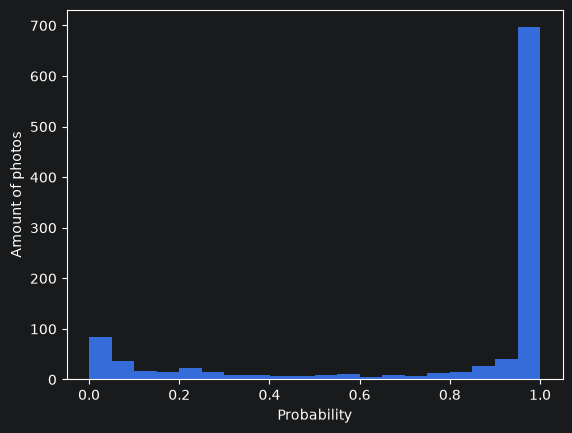

In [90]:
plt.hist(all_probs, bins=20)
plt.xlabel("Probability")
plt.ylabel("Amount of photos")
plt.show()

### Confusion matrix

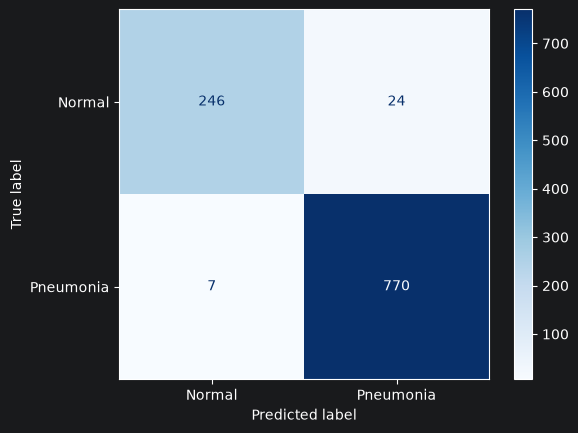

In [115]:
conf_matrix = confusion_matrix(all_labels, predict)
display = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Normal", "Pneumonia"])
display.plot(cmap="Blues")
plt.show()

In [116]:
recall = conf_matrix[1][1] / (conf_matrix[1][1] + conf_matrix[1][0])
precision = conf_matrix[1][1] / (conf_matrix[1][1] + conf_matrix[0][1])
print(f"Recall: {recall:.3f}, Precision: {precision:.3f}")

Recall: 0.991, Precision: 0.970


## FN and FP cases

In [128]:
fn_indices = [i for i, (true, pred) in enumerate(zip(all_labels, predict)) if true == 1 and pred == 0]
fp_indices = [i for i, (true, pred) in enumerate(zip(all_labels, predict)) if true == 0 and pred == 1]

fn_idxs = [val_indices[i] for i in fn_indices]
fp_idxs = [val_indices[i] for i in fp_indices]

fn_subset = Subset(val_data, fn_idxs)
fp_subset = Subset(val_data, fp_idxs)

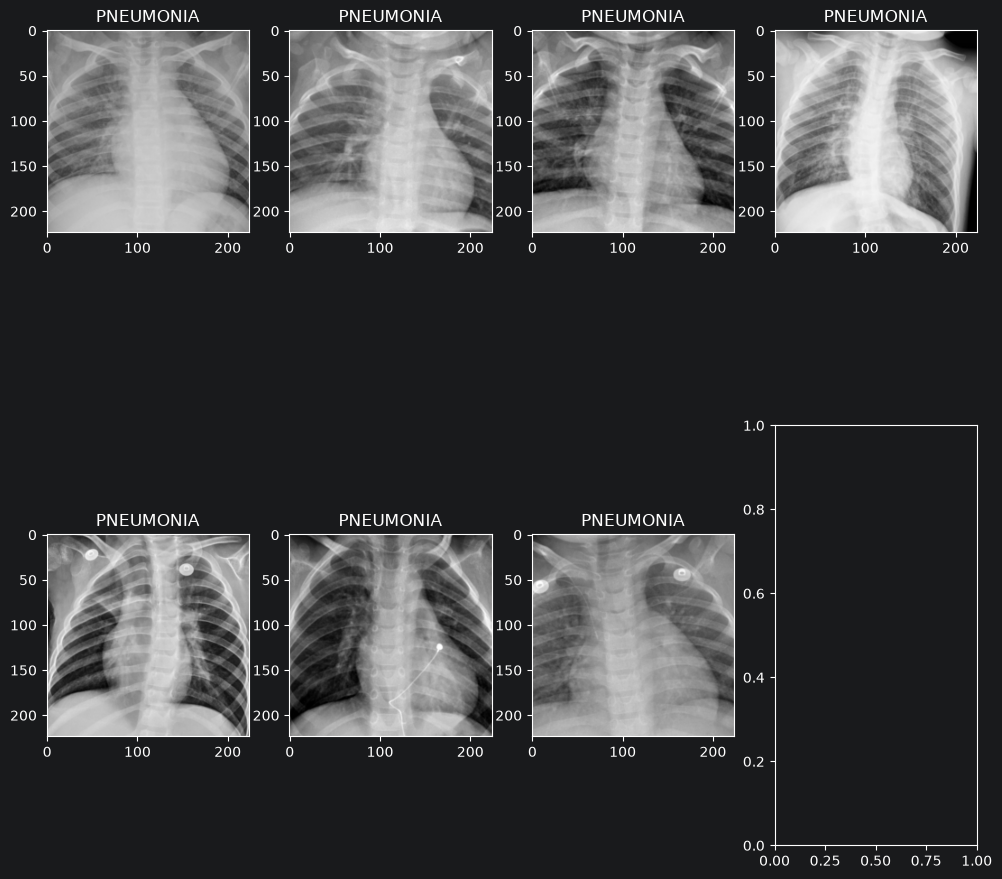

In [129]:
fig, axes = plt.subplots(2, 4, figsize=(12, 12))
axes = axes.flatten()

for i in range(len(fn_subset)):
    img, label = fn_subset[i]
    img = img.cpu()
    img_denorm = denormalize(img, std, mean)
    axes[i].imshow(img_denorm.permute(1, 2, 0), cmap='gray')
    axes[i].set_title(val_data.classes[label])

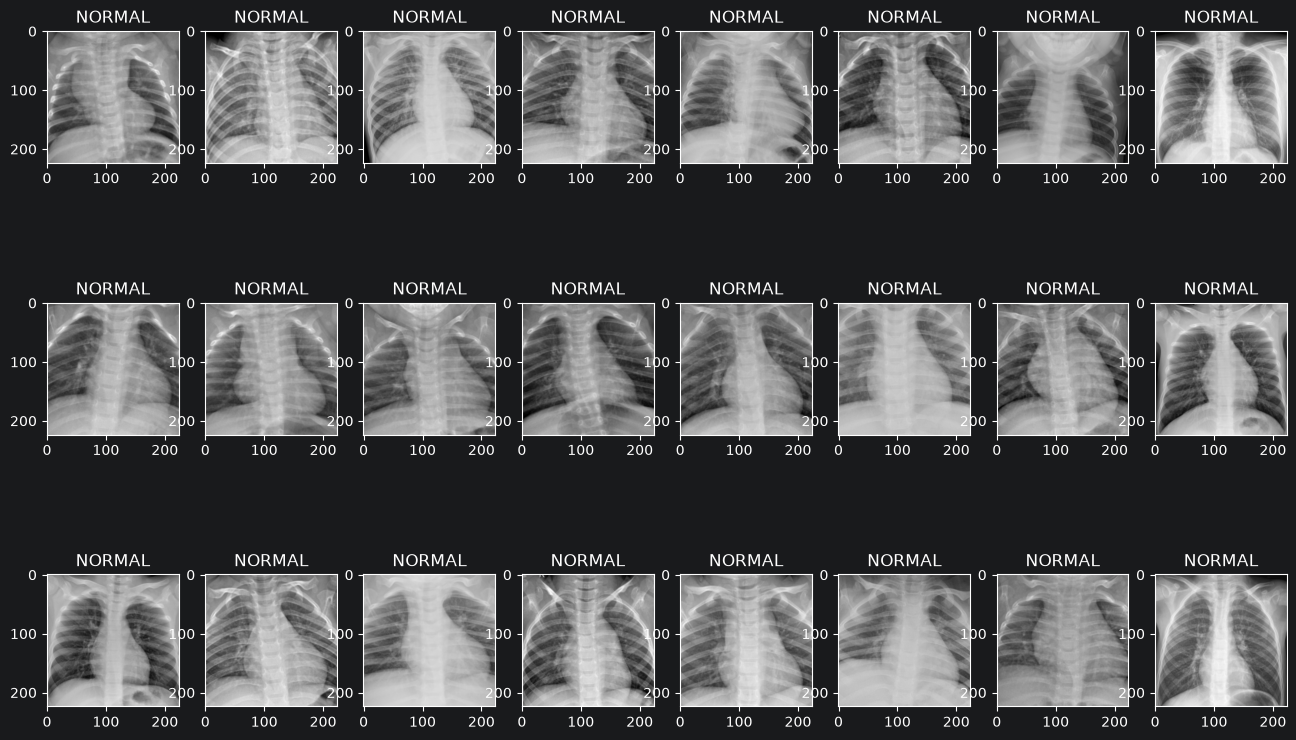

In [133]:
fig, axes = plt.subplots(3, 8, figsize=(16, 10))
axes = axes.flatten()

for i in range(len(fp_subset)):
    img, label = fp_subset[i]
    img = img.cpu()
    img_denorm = denormalize(img, std, mean)
    axes[i].imshow(img_denorm.permute(1, 2, 0), cmap='gray')
    axes[i].set_title(val_data.classes[label])